In [4]:
import requests
import folium
import geopandas as gpd
from shapely.geometry import shape
from pyproj import CRS
import json
import os

Memanggil API

In [19]:
urls = {"risiko_banjir":'https://geoserver.mapid.io/layers_new/get_layer?api_key=96182a49207a421f974977b4cc184c61&layer_id=698e035302ca69c9817a2538&project_id=698dcfe49e209fa19435595f',
        "tingkat_polusi":'https://geoserver.mapid.io/layers_new/get_layer?api_key=96182a49207a421f974977b4cc184c61&layer_id=6992bc67e12474627a9f0e3e&project_id=698dcfe49e209fa19435595f',
        "kepadatan_penduduk":'https://geoserver.mapid.io/layers_new/get_layer?api_key=96182a49207a421f974977b4cc184c61&layer_id=69929f4d9e209fa194ce1af9&project_id=698dcfe49e209fa19435595f',
        "luas_RTH":'https://geoserver.mapid.io/layers_new/get_layer?api_key=96182a49207a421f974977b4cc184c61&layer_id=6992a4289e209fa194d035ff&project_id=698dcfe49e209fa19435595f'
        }

Mengkonversi data API menjadi GeoDataFrame

In [20]:
import geopandas as gpd
import requests  # WAJIB ADA

def get_gdf_from_api(url):
    response = requests.get(url)  # pakai requests
    if response.status_code == 200:
        geojson = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson['features'])
        print(f"Berhasil Mengambil Data Dari {url.split('&layer_id=')[1][:10]}...")
        return gdf
    else:
        print(f"Gagal mengambil data dari {url}")
        return gpd.GeoDataFrame()

gdfs = {}

for key, url in urls.items():
    gdfs[key] = get_gdf_from_api(url)


Berhasil Mengambil Data Dari 698e035302...
Berhasil Mengambil Data Dari 6992bc67e1...
Berhasil Mengambil Data Dari 69929f4d9e...
Berhasil Mengambil Data Dari 6992a4289e...


Pemeriksaan & Penyesuaian Data

In [21]:
from pyproj import CRS
for key, gdf in gdfs.items():
    for col in gdf.columns :
        if gdf[col].dtype == '0':
            gdf[col] = gdf[col].fillna('Tidak Diketahui')
        else:
            gdf[col] = gdf[col].fillna(0)
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf.set_crs(epsg=4326, inplace=True)
        gdfs[key] = gdf
print("Semua Data sudah dicek dan disesuaikan")

Semua Data sudah dicek dan disesuaikan


visualisasi data setiap variabel

In [22]:
import folium

for key, gdf in gdfs.items():
    m = folium.Map(location=[-6.167, 106.758], zoom_start=12)
    folium.GeoJson(gdf).add_to(m)
    folium.LayerControl().add_to(m)
    display(m)
    print(f"Peta untuk variabel: {key}")


Peta untuk variabel: risiko_banjir


Peta untuk variabel: tingkat_polusi


Peta untuk variabel: kepadatan_penduduk


Peta untuk variabel: luas_RTH


overlay/intersect data spatial multi variabel

In [25]:
import geopandas as gpd

for key in gdfs.keys():
    if 'ID' in gdfs[key].columns:
        gdfs[key] = gdfs[key].drop(columns=['ID'])

gdf_list = [
    gdfs['kepadatan_penduduk'],
    gdfs['risiko_banjir'],
    gdfs['tingkat_polusi'],
    gdfs['luas_RTH'] 
    ]

def overlay_multiple(gdf_list):
    result = gdf_list[0]
    
    for gdf in gdf_list[1:]:
        if not gdf.empty:
            result = gpd.overlay(result, gdf, how='intersection')
            result = result[result.is_valid]
    return result

gdf_intersect = overlay_multiple(gdf_list)
print(f"Jumlah area hasil intersect: {len(gdf_intersect)}")
print("Kolom hasil intersect:", gdf_intersect.columns)



    

Jumlah area hasil intersect: 222
Kolom hasil intersect: Index(['ADMINISTRASI_1', 'KECAMATAN_1', 'Kepadatan Penduduk',
       'Kelas Kepadatan Penduduk', 'ID_PROV', 'PROVINSI', 'ID_KABKOT',
       'KABKOT', 'ID_KEC', 'KECAMATAN_2', 'ID_DESA', 'DESA', 'KELAS_RISIKO',
       'Administrasi', 'Kecamatan', 'Tingkat Polusi', 'ADMINISTRASI_2',
       'KECAMATAN', 'LUAS RTH', 'geometry'],
      dtype='str')


d:\mapid\MAPID_WEBGIS_PYTHON\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 208 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
d:\mapid\MAPID_WEBGIS_PYTHON\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 205 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


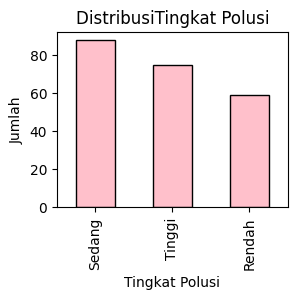

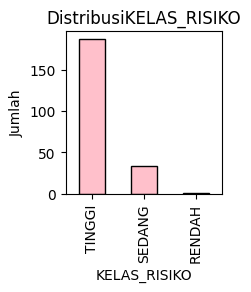

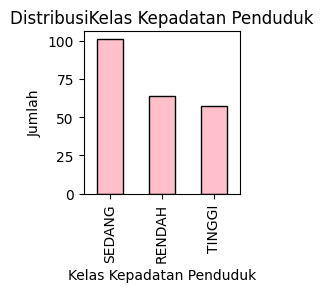

In [35]:
import matplotlib.pyplot as plt
kategori_cols = ['Tingkat Polusi', 'KELAS_RISIKO', 'Kelas Kepadatan Penduduk']
plt.figure(figsize=(8, 5))
for i, col in enumerate(kategori_cols, 1):
    if col in gdf_intersect.columns:
        plt.subplot(2, 3, i)
        gdf_intersect[col].value_counts().plot(kind='bar', color='pink', edgecolor='black')
        plt.title(f'Distribusi{col}')
        plt.xlabel(col)
        plt.ylabel('Jumlah')
        plt.tight_layout()
        plt.show()

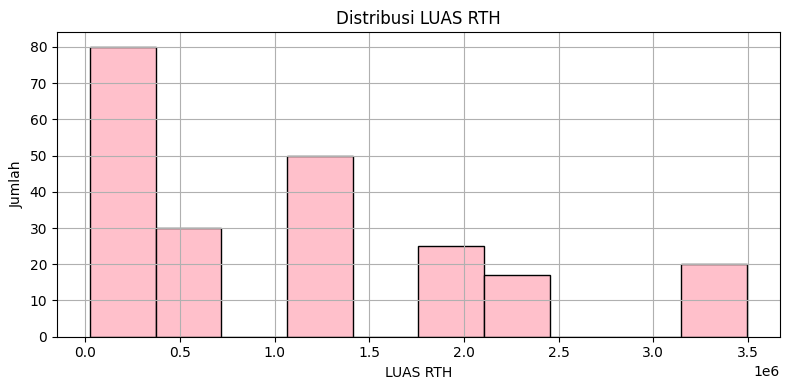

In [40]:
import matplotlib.pyplot as plt

numerik_cols = []

if 'LUAS RTH' in gdf_intersect.columns:
    numerik_cols.append('LUAS RTH')

if numerik_cols:
    plt.figure(figsize=(8, 4))

    for i, col in enumerate(numerik_cols, 1):
        plt.subplot(1, len(numerik_cols), i)
        gdf_intersect[col].dropna().hist(
            bins=10, color='pink', edgecolor='black'
        )
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.ylabel('Jumlah')

    plt.tight_layout()
    plt.show()




Skoring dan Klasifikasi Kesesuaian Lokasi

In [44]:
import pandas as pd

def skoring(row):
    skor = 0
    
    #Kepadatan Penduduk
    skor += {
        "RENDAH": 3,
        "SEDANG": 2,
        "TINGGI": 1
    }.get(str(row.get("Kepadatan Penduduk", "")).upper(), 0)
    
    #Risiko Banjir (pakai KELAS_RISIKO)
    skor += {
        "RENDAH": 3,
        "SEDANG": 2,
        "TINGGI": 1
    }.get(str(row.get("KELAS_RISIKO", "")).upper(), 0)
    
    #Tingkat Polusi
    skor += {
        "RENDAH": 3,
        "SEDANG": 2,
        "TINGGI": 1
    }.get(str(row.get("Tingkat Polusi", "")).upper(), 0)
    
    #Luas RTH (numerik)
    luas = row.get("LUAS RTH", 0)
    skor += 3 if luas > 10000 else 2 if luas > 5000 else 1
    
    return skor


#Hitung skor total
gdf_intersect['SKOR_TOTAL'] = gdf_intersect.apply(skoring, axis=1)


#Klasifikasi kesesuaian
gdf_intersect['KESESUAIAN'] = pd.cut(
    gdf_intersect['SKOR_TOTAL'],
    bins=[0, 6, 9, 12],
    labels=['RENDAH', 'SEDANG', 'TINGGI'],
    include_lowest=True
)

print(gdf_intersect[['SKOR_TOTAL', 'KESESUAIAN']])

     SKOR_TOTAL KESESUAIAN
0             5     RENDAH
1             5     RENDAH
2             5     RENDAH
3             6     RENDAH
4             5     RENDAH
..          ...        ...
217           7     SEDANG
218           7     SEDANG
219           7     SEDANG
220           7     SEDANG
221           7     SEDANG

[222 rows x 2 columns]


Visualisasi Hasil Skoring dan Kesesuaian Lokasi

In [48]:
import folium

label_to_color = {
    'RENDAH': 'red',
    'SEDANG': 'orange',
    'TINGGI': 'green'
}

def style_function(feature):
    kategori = feature['properties'].get('KESESUAIAN', 'RENDAH')
    return {
        'fillColor': label_to_color.get(kategori, 'gray'),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6
    }

#Jakarta Barat
m = folium.Map(location=[-6.168, 106.758], zoom_start=12)

folium.GeoJson(
    gdf_intersect,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['SKOR_TOTAL', 'KESESUAIAN'],
        aliases=['Skor Total:', 'Kesesuaian:']
    )
).add_to(m)

m

Menyimpan hasil ke GeoJSON

In [49]:
output_dir = r"D:\mapid\MAPID_WEBGIS_PYTHON\labs\taks 6"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Hasil_Analisis_Lokasi_RTH.geojson")
gdf_intersect.to_file(output_path, driver='GeoJSON')
print(f"Hasil analisis berhasil disimpan di: {output_path}")

Hasil analisis berhasil disimpan di: D:\mapid\MAPID_WEBGIS_PYTHON\labs\taks 6\Hasil_Analisis_Lokasi_RTH.geojson


Analisis Statistik dan Eksplorasi Data

In [51]:
#Statistik Deskriptif
print("Statistil Deskriptif Numerik:")
print(gdf_intersect[['SKOR_TOTAL', 'LUAS RTH']].describe())

print("\nDistribusi Kategori Kesesuaian")
print(gdf_intersect['KESESUAIAN'].value_counts())

print("\nKorelasi antar variabel numerik:")
print(gdf_intersect[['SKOR_TOTAL','LUAS RTH']].corr())

Statistil Deskriptif Numerik:
       SKOR_TOTAL      LUAS RTH
count  222.000000  2.220000e+02
mean     6.090090  1.089182e+06
std      0.779251  1.033221e+06
min      5.000000  2.370500e+04
25%      6.000000  3.456580e+05
50%      6.000000  1.131933e+06
75%      7.000000  2.036570e+06
max      8.000000  3.495289e+06

Distribusi Kategori Kesesuaian
KESESUAIAN
RENDAH    154
SEDANG     68
TINGGI      0
Name: count, dtype: int64

Korelasi antar variabel numerik:
            SKOR_TOTAL  LUAS RTH
SKOR_TOTAL    1.000000 -0.099919
LUAS RTH     -0.099919  1.000000


Menentukan dan Visualisasi Lokasi Optimal

In [56]:
# Cari skor maksimum
max_skor = gdf_intersect['SKOR_TOTAL'].max()

# Filter lokasi dengan skor maksimum
lokasi_optimal = gdf_intersect[gdf_intersect['SKOR_TOTAL'] == max_skor]

print(f"Jumlah Lokasi Optimal (skor tertinggi): {len(lokasi_optimal)}")
print("Atribut Lokasi Optimal:")
print(lokasi_optimal[['SKOR_TOTAL', 'KESESUAIAN', 'KELAS_RISIKO', 'Kepadatan Penduduk', 'Tingkat Polusi', 'LUAS RTH']])


Jumlah Lokasi Optimal (skor tertinggi): 5
Atribut Lokasi Optimal:
     SKOR_TOTAL KESESUAIAN KELAS_RISIKO  Kepadatan Penduduk Tingkat Polusi  \
179           8     SEDANG       SEDANG            20552432         Rendah   
180           8     SEDANG       SEDANG            20552432         Rendah   
181           8     SEDANG       SEDANG            20552432         Rendah   
182           8     SEDANG       SEDANG            20552432         Rendah   
183           8     SEDANG       SEDANG            20552432         Rendah   

     LUAS RTH  
179   3495289  
180   3495289  
181   3495289  
182   3495289  
183   3495289  


In [59]:
import folium

m_optimal = folium.Map(location=[-6.168, 106.758], zoom_start=12)

def style_optimal(feature):
    return {
        'fillColor': 'lime',
        'color': 'blue',
        'weight': 3,
        'fillOpacity': 0.7
    }

folium.GeoJson(
    lokasi_optimal,
    style_function=style_optimal,
    tooltip=folium.GeoJsonTooltip(
        fields=['SKOR_TOTAL', 'KESESUAIAN']
    )
).add_to(m_optimal)

folium.LayerControl().add_to(m_optimal)

m_optimal


Analisis Lanjutan dan insight Lokasi Optimal

In [60]:
#Buffer 500 meter dari lokasi optimal
lokasi_optimal['buffer_500m']=lokasi_optimal.geometry.buffer(0.005)
print("Statistik Lokasi Optimal:")
print(lokasi_optimal.describe(include='all'))

Statistik Lokasi Optimal:
       ADMINISTRASI_1 KECAMATAN_1  Kepadatan Penduduk  \
count               5           5                 5.0   
unique              1           1                 NaN   
top     Jakarta Barat    Palmerah                 NaN   
freq                5           5                 NaN   
mean              NaN         NaN          20552432.0   
std               NaN         NaN                 0.0   
min               NaN         NaN          20552432.0   
25%               NaN         NaN          20552432.0   
50%               NaN         NaN          20552432.0   
75%               NaN         NaN          20552432.0   
max               NaN         NaN          20552432.0   

       Kelas Kepadatan Penduduk ID_PROV     PROVINSI ID_KABKOT  \
count                         5       5            5         5   
unique                        1       1            1         1   
top                      TINGGI      31  DKI JAKARTA     31.73   
freq                     

C:\Users\ACER\AppData\Local\Temp\ipykernel_46988\3608755092.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lokasi_optimal['buffer_500m']=lokasi_optimal.geometry.buffer(0.005)


In [62]:
import geopandas as gpd
import os
from shapely.geometry import Polygon, MultiPolygon

buffer_gdf = lokasi_optimal.copy()
buffer_gdf = buffer_gdf.set_geometry(buffer_gdf['buffer_500m'])

if 'geometry' in buffer_gdf.columns and buffer_gdf.geometry.name != 'geometry':
    buffer_gdf = buffer_gdf.drop(columns=['geometry'])

buffer_gdf = buffer_gdf[buffer_gdf.geometry.notnull()]
buffer_gdf = buffer_gdf[buffer_gdf.geometry.apply(lambda x: x.is_valid and isinstance(x, (Polygon, MultiPolygon)))]

output_dir= r"D:\mapid\MAPID_WEBGIS_PYTHON\labs\taks 6"
os.makedirs(output_dir,exist_ok=True)
output_path = os.path.join(output_dir,"buffer_lokasi_optimal_RTH.geojson")

buffer_gdf.to_file(output_path, driver='GeoJSON')
print(f"BUffer lokasi optimal berhasil diekspor ke: {output_path}")

BUffer lokasi optimal berhasil diekspor ke: D:\mapid\MAPID_WEBGIS_PYTHON\labs\taks 6\buffer_lokasi_optimal_RTH.geojson
